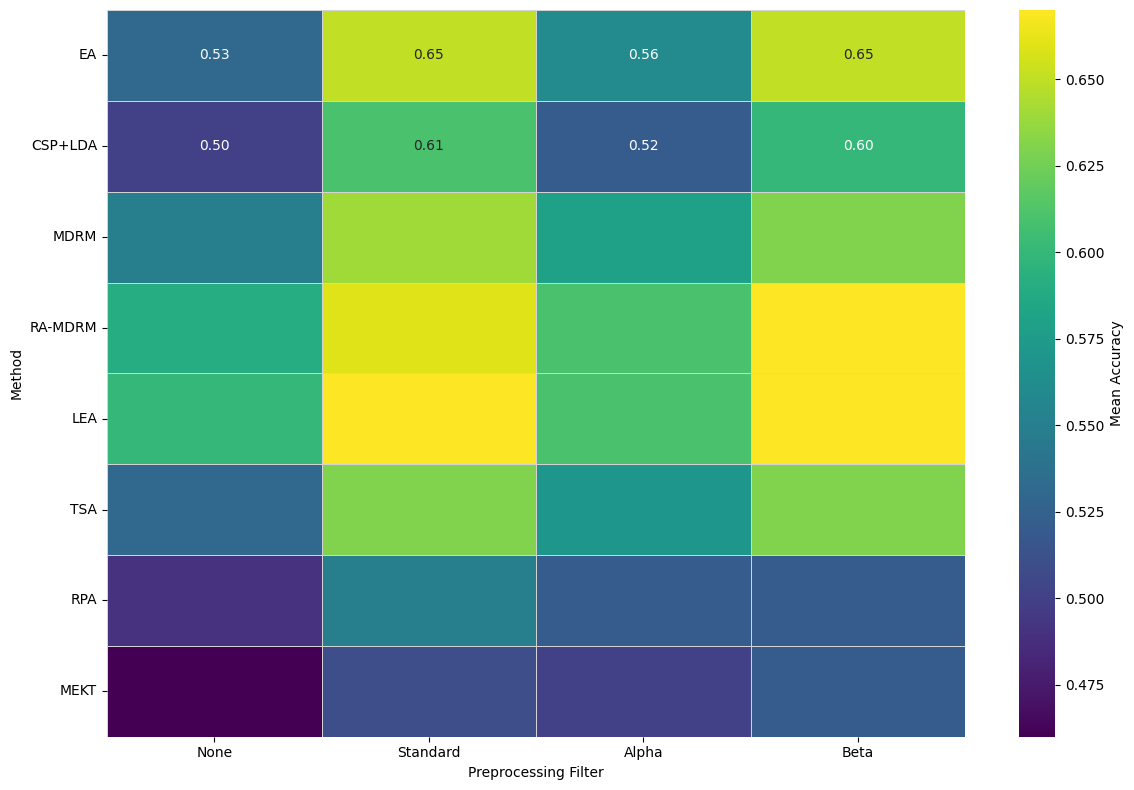

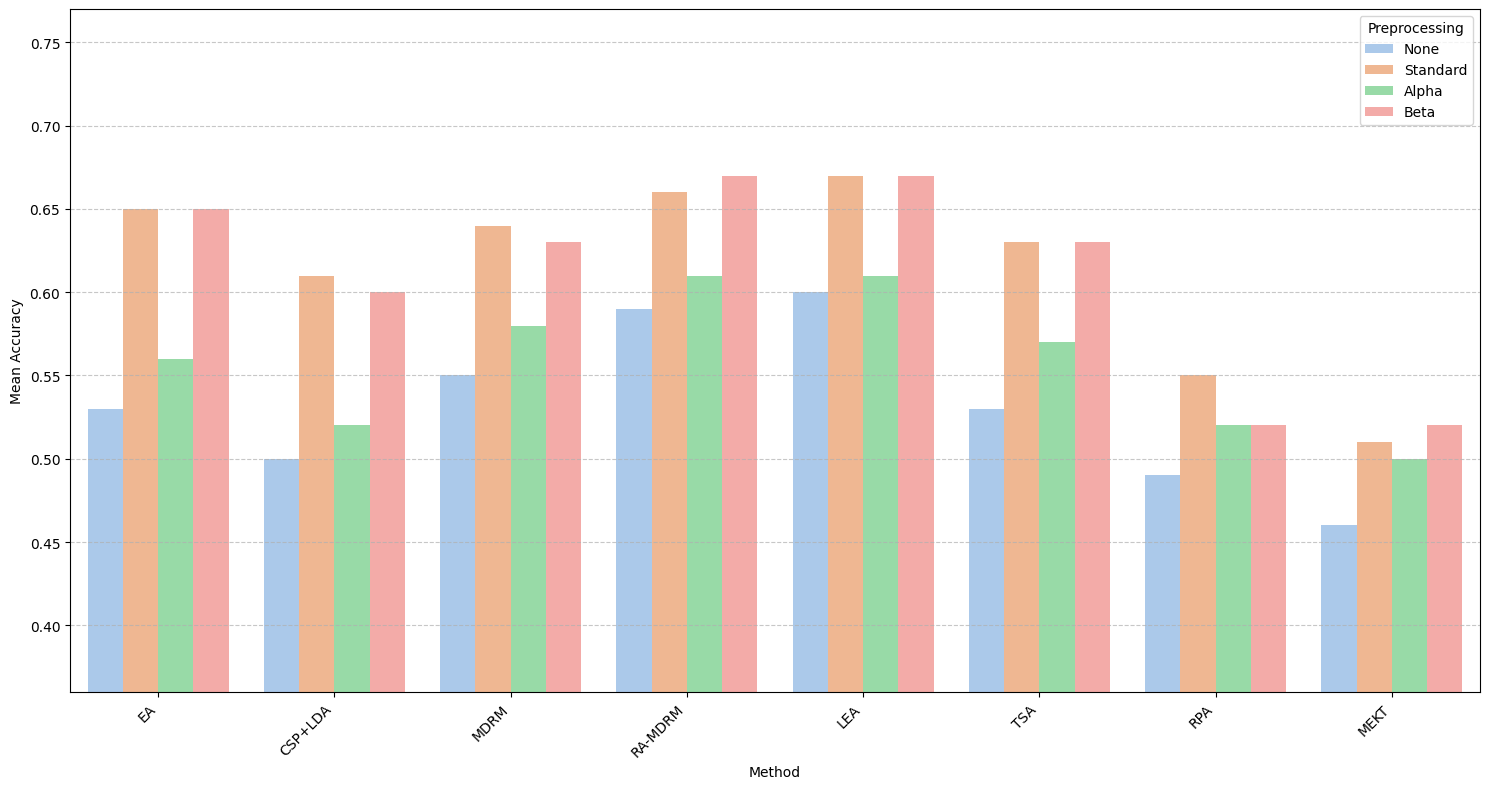

In [4]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Raw data string for the second dataset
data2 = """
EA - 4 class

None
Subject 1 Test Accuracy: 0.61
Subject 2 Test Accuracy: 0.45
Subject 3 Test Accuracy: 0.73
Subject 4 Test Accuracy: 0.39
Subject 5 Test Accuracy: 0.36
Subject 6 Test Accuracy: 0.33
Subject 7 Test Accuracy: 0.58
Subject 8 Test Accuracy: 0.59
Subject 9 Test Accuracy: 0.68
Mean Cross-Validation Accuracy: 0.53 ± 0.14

Standard
Subject 1 Test Accuracy: 0.76
Subject 2 Test Accuracy: 0.52
Subject 3 Test Accuracy: 0.77
Subject 4 Test Accuracy: 0.66
Subject 5 Test Accuracy: 0.38
Subject 6 Test Accuracy: 0.51
Subject 7 Test Accuracy: 0.80
Subject 8 Test Accuracy: 0.81
Subject 9 Test Accuracy: 0.67
Mean Cross-Validation Accuracy: 0.65 ± 0.14

Alpha
Subject 1 Test Accuracy: 0.69
Subject 2 Test Accuracy: 0.34
Subject 3 Test Accuracy: 0.77
Subject 4 Test Accuracy: 0.52
Subject 5 Test Accuracy: 0.35
Subject 6 Test Accuracy: 0.46
Subject 7 Test Accuracy: 0.52
Subject 8 Test Accuracy: 0.67
Subject 9 Test Accuracy: 0.68
Mean Cross-Validation Accuracy: 0.56 ± 0.15

Beta
Subject 1 Test Accuracy: 0.82
Subject 2 Test Accuracy: 0.51
Subject 3 Test Accuracy: 0.82
Subject 4 Test Accuracy: 0.63
Subject 5 Test Accuracy: 0.38
Subject 6 Test Accuracy: 0.55
Subject 7 Test Accuracy: 0.88
Subject 8 Test Accuracy: 0.60
Subject 9 Test Accuracy: 0.66
Mean Cross-Validation Accuracy: 0.65 ± 0.16

CSP+LDA: 4 class

None
Subject 1 Test Accuracy: 0.59
Subject 2 Test Accuracy: 0.43
Subject 3 Test Accuracy: 0.73
Subject 4 Test Accuracy: 0.41
Subject 5 Test Accuracy: 0.25
Subject 6 Test Accuracy: 0.31
Subject 7 Test Accuracy: 0.49
Subject 8 Test Accuracy: 0.61
Subject 9 Test Accuracy: 0.66
Mean Cross-Validation Accuracy: 0.50 ± 0.15

Standard
Subject 1 Test Accuracy: 0.78
Subject 2 Test Accuracy: 0.48
Subject 3 Test Accuracy: 0.68
Subject 4 Test Accuracy: 0.62
Subject 5 Test Accuracy: 0.33
Subject 6 Test Accuracy: 0.51
Subject 7 Test Accuracy: 0.62
Subject 8 Test Accuracy: 0.82
Subject 9 Test Accuracy: 0.64
Mean Cross-Validation Accuracy: 0.61 ± 0.14

Alpha
Subject 1 Test Accuracy: 0.67
Subject 2 Test Accuracy: 0.28
Subject 3 Test Accuracy: 0.68
Subject 4 Test Accuracy: 0.47
Subject 5 Test Accuracy: 0.36
Subject 6 Test Accuracy: 0.47
Subject 7 Test Accuracy: 0.50
Subject 8 Test Accuracy: 0.67
Subject 9 Test Accuracy: 0.63
Mean Cross-Validation Accuracy: 0.52 ± 0.14

Beta
Subject 1 Test Accuracy: 0.79
Subject 2 Test Accuracy: 0.50
Subject 3 Test Accuracy: 0.80
Subject 4 Test Accuracy: 0.61
Subject 5 Test Accuracy: 0.34
Subject 6 Test Accuracy: 0.51
Subject 7 Test Accuracy: 0.75
Subject 8 Test Accuracy: 0.52
Subject 9 Test Accuracy: 0.60
Mean Cross-Validation Accuracy: 0.60 ± 0.14

MDRM: 4 Class:

None
Subject 1 Test Accuracy: 0.65
Subject 2 Test Accuracy: 0.42
Subject 3 Test Accuracy: 0.67
Subject 4 Test Accuracy: 0.54
Subject 5 Test Accuracy: 0.26
Subject 6 Test Accuracy: 0.40
Subject 7 Test Accuracy: 0.57
Subject 8 Test Accuracy: 0.75
Subject 9 Test Accuracy: 0.70
Mean Cross-Validation Accuracy: 0.55 ± 0.15

Standard
Subject 1 Test Accuracy: 0.81
Subject 2 Test Accuracy: 0.51
Subject 3 Test Accuracy: 0.70
Subject 4 Test Accuracy: 0.67
Subject 5 Test Accuracy: 0.44
Subject 6 Test Accuracy: 0.49
Subject 7 Test Accuracy: 0.60
Subject 8 Test Accuracy: 0.74
Subject 9 Test Accuracy: 0.76
Mean Cross-Validation Accuracy: 0.64 ± 0.12
Alpha
Subject 1 Test Accuracy: 0.76
Subject 2 Test Accuracy: 0.35
Subject 3 Test Accuracy: 0.70
Subject 4 Test Accuracy: 0.49
Subject 5 Test Accuracy: 0.43
Subject 6 Test Accuracy: 0.44
Subject 7 Test Accuracy: 0.52
Subject 8 Test Accuracy: 0.77
Subject 9 Test Accuracy: 0.76
Mean Cross-Validation Accuracy: 0.58 ± 0.16

Beta
Subject 1 Test Accuracy: 0.81
Subject 2 Test Accuracy: 0.56
Subject 3 Test Accuracy: 0.67
Subject 4 Test Accuracy: 0.68
Subject 5 Test Accuracy: 0.47
Subject 6 Test Accuracy: 0.47
Subject 7 Test Accuracy: 0.71
Subject 8 Test Accuracy: 0.62
Subject 9 Test Accuracy: 0.70
Mean Cross-Validation Accuracy: 0.63 ± 0.11

RA-MDRM: 4 class

None
Subject 1 Test Accuracy: 0.66
Subject 2 Test Accuracy: 0.46
Subject 3 Test Accuracy: 0.67
Subject 4 Test Accuracy: 0.54
Subject 5 Test Accuracy: 0.43
Subject 6 Test Accuracy: 0.44
Subject 7 Test Accuracy: 0.57
Subject 8 Test Accuracy: 0.76
Subject 9 Test Accuracy: 0.75
Mean Cross-Validation Accuracy: 0.59 ± 0.12

Standard
Subject 1 Test Accuracy: 0.77
Subject 2 Test Accuracy: 0.55
Subject 3 Test Accuracy: 0.79
Subject 4 Test Accuracy: 0.66
Subject 5 Test Accuracy: 0.42
Subject 6 Test Accuracy: 0.48
Subject 7 Test Accuracy: 0.76
Subject 8 Test Accuracy: 0.77
Subject 9 Test Accuracy: 0.76
Mean Cross-Validation Accuracy: 0.66 ± 0.14

Alpha
Subject 1 Test Accuracy: 0.71
Subject 2 Test Accuracy: 0.40
Subject 3 Test Accuracy: 0.77
Subject 4 Test Accuracy: 0.54
Subject 5 Test Accuracy: 0.44
Subject 6 Test Accuracy: 0.42
Subject 7 Test Accuracy: 0.57
Subject 8 Test Accuracy: 0.81
Subject 9 Test Accuracy: 0.80
Mean Cross-Validation Accuracy: 0.61 ± 0.16

Beta
Subject 1 Test Accuracy: 0.83
Subject 2 Test Accuracy: 0.56
Subject 3 Test Accuracy: 0.76
Subject 4 Test Accuracy: 0.67
Subject 5 Test Accuracy: 0.46
Subject 6 Test Accuracy: 0.51
Subject 7 Test Accuracy: 0.84
Subject 8 Test Accuracy: 0.69
Subject 9 Test Accuracy: 0.72
Mean Cross-Validation Accuracy: 0.67 ± 0.13


LEA: 4 class

None
Subject 1 Test Accuracy: 0.65
Subject 2 Test Accuracy: 0.47
Subject 3 Test Accuracy: 0.71
Subject 4 Test Accuracy: 0.54
Subject 5 Test Accuracy: 0.43
Subject 6 Test Accuracy: 0.45
Subject 7 Test Accuracy: 0.65
Subject 8 Test Accuracy: 0.78
Subject 9 Test Accuracy: 0.71

Mean Cross-Validation Accuracy: 0.60 ± 0.12

Standard
Subject 1 Test Accuracy: 0.80
Subject 2 Test Accuracy: 0.56
Subject 3 Test Accuracy: 0.81
Subject 4 Test Accuracy: 0.64
Subject 5 Test Accuracy: 0.42
Subject 6 Test Accuracy: 0.48
Subject 7 Test Accuracy: 0.77
Subject 8 Test Accuracy: 0.80
Subject 9 Test Accuracy: 0.73

Mean Cross-Validation Accuracy: 0.67 ± 0.14

Alpha
Subject 1 Test Accuracy: 0.77
Subject 2 Test Accuracy: 0.39
Subject 3 Test Accuracy: 0.80
Subject 4 Test Accuracy: 0.54
Subject 5 Test Accuracy: 0.42
Subject 6 Test Accuracy: 0.43
Subject 7 Test Accuracy: 0.61
Subject 8 Test Accuracy: 0.81
Subject 9 Test Accuracy: 0.76

Mean Cross-Validation Accuracy: 0.61 ± 0.16

Beta
Subject 1 Test Accuracy: 0.83
Subject 2 Test Accuracy: 0.56
Subject 3 Test Accuracy: 0.76
Subject 4 Test Accuracy: 0.65
Subject 5 Test Accuracy: 0.44
Subject 6 Test Accuracy: 0.52
Subject 7 Test Accuracy: 0.85
Subject 8 Test Accuracy: 0.76
Subject 9 Test Accuracy: 0.68

Mean Cross-Validation Accuracy: 0.67 ± 0.13


TSA: 4 class
None
Subject 1 Test Accuracy: 0.59
Subject 2 Test Accuracy: 0.38
Subject 3 Test Accuracy: 0.68
Subject 4 Test Accuracy: 0.48
Subject 5 Test Accuracy: 0.32
Subject 6 Test Accuracy: 0.35
Subject 7 Test Accuracy: 0.59
Subject 8 Test Accuracy: 0.75
Subject 9 Test Accuracy: 0.67

Mean Cross-Validation Accuracy: 0.53 ± 0.15

Standard
Subject 1 Test Accuracy: 0.80
Subject 2 Test Accuracy: 0.51
Subject 3 Test Accuracy: 0.78
Subject 4 Test Accuracy: 0.56
Subject 5 Test Accuracy: 0.41
Subject 6 Test Accuracy: 0.47
Subject 7 Test Accuracy: 0.68
Subject 8 Test Accuracy: 0.75
Subject 9 Test Accuracy: 0.70

Mean Cross-Validation Accuracy: 0.63 ± 0.14

Alpha
Subject 1 Test Accuracy: 0.73
Subject 2 Test Accuracy: 0.37
Subject 3 Test Accuracy: 0.75
Subject 4 Test Accuracy: 0.47
Subject 5 Test Accuracy: 0.41
Subject 6 Test Accuracy: 0.35
Subject 7 Test Accuracy: 0.52
Subject 8 Test Accuracy: 0.78
Subject 9 Test Accuracy: 0.73

Mean Cross-Validation Accuracy: 0.57 ± 0.17

Beta
Subject 1 Test Accuracy: 0.74
Subject 2 Test Accuracy: 0.53
Subject 3 Test Accuracy: 0.73
Subject 4 Test Accuracy: 0.66
Subject 5 Test Accuracy: 0.41
Subject 6 Test Accuracy: 0.45
Subject 7 Test Accuracy: 0.79
Subject 8 Test Accuracy: 0.65
Subject 9 Test Accuracy: 0.71

Mean Cross-Validation Accuracy: 0.63 ± 0.13


RPA: 4 class

None
Subject 1 Test Accuracy: 0.55
Subject 2 Test Accuracy: 0.35
Subject 3 Test Accuracy: 0.46
Subject 4 Test Accuracy: 0.44
Subject 5 Test Accuracy: 0.44
Subject 6 Test Accuracy: 0.37
Subject 7 Test Accuracy: 0.46
Subject 8 Test Accuracy: 0.65
Subject 9 Test Accuracy: 0.65

Mean Cross-Validation Accuracy: 0.49 ± 0.10
Standard
Subject 1 Test Accuracy: 0.65
Subject 2 Test Accuracy: 0.37
Subject 3 Test Accuracy: 0.66
Subject 4 Test Accuracy: 0.59
Subject 5 Test Accuracy: 0.38
Subject 6 Test Accuracy: 0.38
Subject 7 Test Accuracy: 0.62
Subject 8 Test Accuracy: 0.63
Subject 9 Test Accuracy: 0.67

Mean Cross-Validation Accuracy: 0.55 ± 0.13

Alpha
Subject 1 Test Accuracy: 0.66
Subject 2 Test Accuracy: 0.33
Subject 3 Test Accuracy: 0.63
Subject 4 Test Accuracy: 0.48
Subject 5 Test Accuracy: 0.37
Subject 6 Test Accuracy: 0.36
Subject 7 Test Accuracy: 0.52
Subject 8 Test Accuracy: 0.61
Subject 9 Test Accuracy: 0.69

Mean Cross-Validation Accuracy: 0.52 ± 0.13

Beta
Subject 1 Test Accuracy: 0.59
Subject 2 Test Accuracy: 0.39
Subject 3 Test Accuracy: 0.57
Subject 4 Test Accuracy: 0.52
Subject 5 Test Accuracy: 0.38
Subject 6 Test Accuracy: 0.36
Subject 7 Test Accuracy: 0.66
Subject 8 Test Accuracy: 0.60
Subject 9 Test Accuracy: 0.62

Mean Cross-Validation Accuracy: 0.52 ± 0.11

MEKT: 4 class

None
Subject 1 Test Accuracy: 0.21
Subject 2 Test Accuracy: 0.55
Subject 3 Test Accuracy: 0.72
Subject 4 Test Accuracy: 0.27
Subject 5 Test Accuracy: 0.41
Subject 6 Test Accuracy: 0.23
Subject 7 Test Accuracy: 0.66
Subject 8 Test Accuracy: 0.85
Subject 9 Test Accuracy: 0.22
Mean Cross-Validation Accuracy: 0.46 ± 0.23

Standard
Subject 1 Test Accuracy: 0.21
Subject 2 Test Accuracy: 0.67
Subject 3 Test Accuracy: 0.89
Subject 4 Test Accuracy: 0.23
Subject 5 Test Accuracy: 0.43
Subject 6 Test Accuracy: 0.23
Subject 7 Test Accuracy: 0.84
Subject 8 Test Accuracy: 0.91
Subject 9 Test Accuracy: 0.22
Mean Cross-Validation Accuracy: 0.51 ± 0.29

Alpha
Subject 1 Test Accuracy: 0.23
Subject 2 Test Accuracy: 0.51
Subject 3 Test Accuracy: 0.86
Subject 4 Test Accuracy: 0.29
Subject 5 Test Accuracy: 0.48
Subject 6 Test Accuracy: 0.26
Subject 7 Test Accuracy: 0.79
Subject 8 Test Accuracy: 0.90
Subject 9 Test Accuracy: 0.22
Mean Cross-Validation Accuracy: 0.50 ± 0.26

Beta
Subject 1 Test Accuracy: 0.22
Subject 2 Test Accuracy: 0.63
Subject 3 Test Accuracy: 0.87
Subject 4 Test Accuracy: 0.25
Subject 5 Test Accuracy: 0.52
Subject 6 Test Accuracy: 0.26
Subject 7 Test Accuracy: 0.85
Subject 8 Test Accuracy: 0.83
Subject 9 Test Accuracy: 0.24
Mean Cross-Validation Accuracy: 0.52 ± 0.27
"""

# Regex patterns
# Adjusted method pattern to handle optional colon and space variations
method_pattern2 = re.compile(r"^(.*?)(?:\s*-\s*|\s*:\s*)4\s*class", re.IGNORECASE | re.MULTILINE)
# Pattern to find preprocessing type headers
prep_pattern = re.compile(r"^(None|Standard|Alpha|Beta)$", re.MULTILINE)
# Subject and Mean patterns remain the same
subject_pattern = re.compile(r"Subject\s*(\d+)\s*Test Accuracy:\s*([\d.]+)")
mean_pattern = re.compile(r"Mean Cross-Validation Accuracy:\s*([\d.]+)\s*±\s*([\d.]+)")


# --- Parsing Logic for the Second Dataset ---

# Split data by method using the adjusted pattern
split_data2 = method_pattern2.split(data2)

processed_splits2 = []
# Start from index 1, process in steps of 2 (method_name, method_data)
# The pattern captures the method name in group 1, so we take elements at i and i+1
for i in range(1, len(split_data2), 2):
    if i + 1 < len(split_data2):
        method_name = split_data2[i].strip()
        method_data_block = split_data2[i+1].strip()
        # Clean up potential trailing characters like ':' from method name
        method_name = method_name.replace(':', '').strip()
        # Handle edge case like "CSP+LDA" -> "CSP+LDA"
        if not method_name and i > 1: # If name is empty and not the first potential split part
             # This might happen if the pattern splits unexpectedly, try using previous identifier
             # Or log a warning. Let's assume it belongs to the previous structure for now
             # A better approach might need refinement based on exact data anomalies
             print(f"Warning: Empty method name found. Data block:\n{method_data_block[:100]}...")
             # Attempt to associate with the previous method or skip
             # For now, let's skip to avoid incorrect association
             continue

        processed_splits2.append((method_name, method_data_block))
    else:
        # Handle the case where there might be a trailing part after the last method
        if split_data2[i].strip(): # Check if there's significant content
            print(f"Warning: Trailing data after last method found: {split_data2[i][:100]}...")

# Check if processed_splits2 is empty
if not processed_splits2:
    print("Error: No methods were successfully parsed from the second dataset.")
# else:
#     print(f"Successfully parsed {len(processed_splits2)} methods from the second dataset.")
#     for name, block_preview in processed_splits2:
#         print(f"  Method: {name}, Data Preview: {block_preview[:50]}...")


parsed_data2 = []
subject_data2 = []

# Process each method's data block
for method_name, method_data_block in processed_splits2:
    # Find all preprocessing sections within this method block
    prep_matches = list(prep_pattern.finditer(method_data_block))

    if not prep_matches:
        print(f"Warning: No preprocessing sections found for method: {method_name}")
        continue

    for i, current_match in enumerate(prep_matches):
        prep_type = current_match.group(1)
        start_index = current_match.end() # Data starts *after* the keyword

        # Determine the end index for this preprocessing section's data
        if i + 1 < len(prep_matches):
            # End before the start of the next preprocessing keyword
            end_index = prep_matches[i+1].start()
        else:
            # This is the last preprocessing section, goes to the end of the method block
            end_index = len(method_data_block)

        # Extract the data for this specific preprocessing type
        segment_data = method_data_block[start_index:end_index].strip()

        if not segment_data:
             print(f"Warning: Empty data segment found for {method_name} - {prep_type}")
             continue

        # Find mean accuracy and std dev within the segment
        mean_match = mean_pattern.search(segment_data)
        if mean_match:
            mean_acc = float(mean_match.group(1))
            std_dev = float(mean_match.group(2))

            # Append the summary data
            parsed_data2.append({
                "Method": method_name,
                "Preprocessing": prep_type,
                "MeanAccuracy": mean_acc,
                "StdDev": std_dev
            })

            # Find individual subject accuracies within the segment
            subject_matches = subject_pattern.findall(segment_data)
            for subj_num, subj_acc_str in subject_matches:
                try:
                    subject_data2.append({
                        "Method": method_name,
                        "Preprocessing": prep_type,
                        "Subject": int(subj_num),
                        "Accuracy": float(subj_acc_str)
                    })
                except ValueError:
                     print(f"Warning: Could not parse subject data for {method_name} - {prep_type}: Subj={subj_num}, Acc='{subj_acc_str}'")

        else:
            # Check if segment contains subject data even if mean is missing
            if subject_pattern.search(segment_data):
                print(f"Warning: Mean accuracy not found for {method_name} - {prep_type}, although subject data exists.")
            else:
                # This might be an empty segment or formatting issue
                print(f"Warning: No mean accuracy and no subject data found for {method_name} - {prep_type}. Segment content: '{segment_data[:50]}...'")


# Create DataFrames for the second dataset
df_mean2 = pd.DataFrame(parsed_data2)
df_subjects2 = pd.DataFrame(subject_data2)

# --- Verification (Optional) ---
# print("\n--- Second Dataset Mean Accuracies ---")
# print(df_mean2.head())
# print("\n--- Second Dataset Subject Accuracies ---")
# print(df_subjects2.head())
# print("\n--- Second Dataset Mean Info ---")
# print(df_mean2.info())


# --- Visualization for the Second Dataset ---

if not df_mean2.empty:
    # Define a consistent order for preprocessing types and methods
    prep_order = ["None", "Standard", "Alpha", "Beta"]
    # Use the order methods appeared in the data or sort alphabetically
    method_order2 = df_mean2['Method'].unique()
    # method_order2 = sorted(df_mean2['Method'].unique()) # Optional: Sort methods

    plt.figure(figsize=(12, 8))

    # Create the pivot table for the heatmap
    try:
        heatmap_data2 = df_mean2.pivot_table(index="Method", columns="Preprocessing", values="MeanAccuracy")

        # Reindex both rows (Methods) and columns (Preprocessing) to ensure consistent order
        # Fill missing values that might occur if a method doesn't have all prep types with NaN
        heatmap_data2 = heatmap_data2.reindex(index=method_order2, columns=prep_order)

        # print("\n--- Heatmap Data ---")
        # print(heatmap_data2)
        # print("\nNumber of NaN values:", heatmap_data2.isnull().sum().sum()) # Count total NaNs


        sns.heatmap(heatmap_data2, annot=True, fmt=".2f", cmap="viridis", linewidths=.5, linecolor='lightgray', cbar_kws={'label': 'Mean Accuracy'})
        # plt.title('Mean Cross-Validation Accuracy by Method and Preprocessing Filter')
        plt.xlabel('Preprocessing Filter')
        plt.ylabel('Method')
        plt.xticks(rotation=0) # Horizontal labels are fine here
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"\nError creating heatmap for the second dataset: {e}")
        print("Data used for pivoting:")
        print(df_mean2)

else:
    print("\nNo data available to generate the heatmap for the second dataset.")


# --- Optional: Bar Plot for the Second Dataset ---
if not df_mean2.empty:
    plt.figure(figsize=(15, 8))
    # Create the bar plot
    try:
        sns.barplot(data=df_mean2, x='Method', y='MeanAccuracy', hue='Preprocessing',
                    order=method_order2, hue_order=prep_order, palette='pastel',
                    errcolor='gray', errwidth=1, capsize=.1) # Basic error bars using internal calculation if possible

        # Add mean accuracy values on top of the bars
        # ax = plt.gca()
        # for container in ax.containers:
        #     ax.bar_label(container, fmt='%.2f', label_type='edge', padding=2, size=8)

        # plt.title('Mean Cross-Validation Accuracy by Method and Preprocessing Filter')
        plt.xlabel('Method')
        plt.ylabel('Mean Accuracy')
        plt.xticks(rotation=45, ha='right')
        plt.ylim(bottom=max(0, df_mean2['MeanAccuracy'].min() - 0.1), top=df_mean2['MeanAccuracy'].max() + 0.1) # Adjust y-axis limits
        plt.legend(title='Preprocessing', loc='upper right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"\nError creating bar plot for the second dataset: {e}")
        print("Data used for plotting:")
        print(df_mean2)
else:
    print("\nNo data available to generate the bar plot for the second dataset.")